# Africa Disease Burden Analysis (2000–2021)
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** WHO Global Health Observatory API (live data)  
**Tools:** Python, requests, pandas, matplotlib

---

### Research Questions
1. How does life expectancy vary across 47 African countries?
2. Which countries have improved most over 20 years — and why?
3. How does Ghana compare to regional peers?
4. What is the relationship between child mortality and life expectancy?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Pull WHO Data via API

In [2]:
# life expectancy
url_le = "https://ghoapi.azureedge.net/api/WHOSIS_000001"
df_raw = pd.DataFrame(requests.get(url_le).json()['value'])

# under-5 mortality
url_mort = "https://ghoapi.azureedge.net/api/MDG_0000000007"
df_mort_raw = pd.DataFrame(requests.get(url_mort).json()['value'])

# country names
url_countries = "https://ghoapi.azureedge.net/api/DIMENSION/COUNTRY/DimensionValues"
df_countries = pd.DataFrame(requests.get(url_countries).json()['value'])[['Code','Title']]
df_countries.columns = ['Country_Code', 'Country_Name']

print(f"Life expectancy records: {len(df_raw):,}")
print(f"Mortality records:       {len(df_mort_raw):,}")
print(f"Country reference:       {len(df_countries):,}")

Life expectancy records: 12,936
Mortality records:       63,070
Country reference:       234


## 2. Filter and Clean Data

In [3]:
# filter to Africa, both sexes
africa = df_raw[
    (df_raw['ParentLocation'] == 'Africa') &
    (df_raw['Dim1'] == 'SEX_BTSX')
][['SpatialDim', 'TimeDim', 'NumericValue']].copy()
africa.columns = ['Country_Code', 'Year', 'Life_Expectancy']
africa = africa.dropna(subset=['Life_Expectancy'])

df_mort = df_mort_raw[
    (df_mort_raw['ParentLocation'] == 'Africa') &
    (df_mort_raw['Dim1'] == 'SEX_BTSX')
][['SpatialDim', 'TimeDim', 'NumericValue']].copy()
df_mort.columns = ['Country_Code', 'Year', 'Under5_Mortality']
df_mort = df_mort.dropna(subset=['Under5_Mortality'])

# merge and deduplicate
df_combined = africa.merge(
    df_mort[['Country_Code', 'Year', 'Under5_Mortality']],
    on=['Country_Code', 'Year'], how='inner'
).groupby(['Country_Code', 'Year']).agg(
    {'Life_Expectancy': 'mean', 'Under5_Mortality': 'mean'}
).reset_index()

df_combined = df_combined.merge(df_countries, on='Country_Code', how='left')

print(f"Final dataset: {df_combined.shape}")
print(f"Countries: {df_combined['Country_Code'].nunique()}")
print(f"Years: {df_combined['Year'].min()} to {df_combined['Year'].max()}")

Final dataset: (1034, 5)
Countries: 47
Years: 2000 to 2021


## 3. Summary Statistics

In [4]:
latest_2021 = df_combined[df_combined['Year'] == 2021].sort_values(
    'Life_Expectancy', ascending=False)

print("Top 10 countries by Life Expectancy (2021):")
print(latest_2021[['Country_Name','Life_Expectancy','Under5_Mortality']].head(10).round(1).to_string())

print("\nBottom 10 countries by Life Expectancy (2021):")
print(latest_2021[['Country_Name','Life_Expectancy','Under5_Mortality']].tail(10).round(1).to_string())

print(f"\nAfrica average life expectancy (2021): {latest_2021['Life_Expectancy'].mean():.1f} years")
print(f"Africa average under-5 mortality (2021): {latest_2021['Under5_Mortality'].mean():.1f} per 1,000")

Top 10 countries by Life Expectancy (2021):
              Country_Name  Life_Expectancy  Under5_Mortality
285                Algeria             76.0              22.6
879             Seychelles             74.0              14.7
637              Mauritius             73.4              15.7
263             Cabo Verde             73.2              12.7
835  Sao Tome and Principe             71.2              15.3
615             Mauritania             68.9              40.3
329               Ethiopia             67.8              50.0
769                Senegal             67.8              42.5
747                 Rwanda             67.5              41.6
241                Comoros             67.5              42.4

Bottom 10 countries by Life Expectancy (2021):
                  Country_Name  Life_Expectancy  Under5_Mortality
681                    Namibia             60.4              43.8
703                      Niger             60.0             119.1
901                       Ch

## 4. Life Expectancy Trends — Top 5 and Bottom 5 Countries

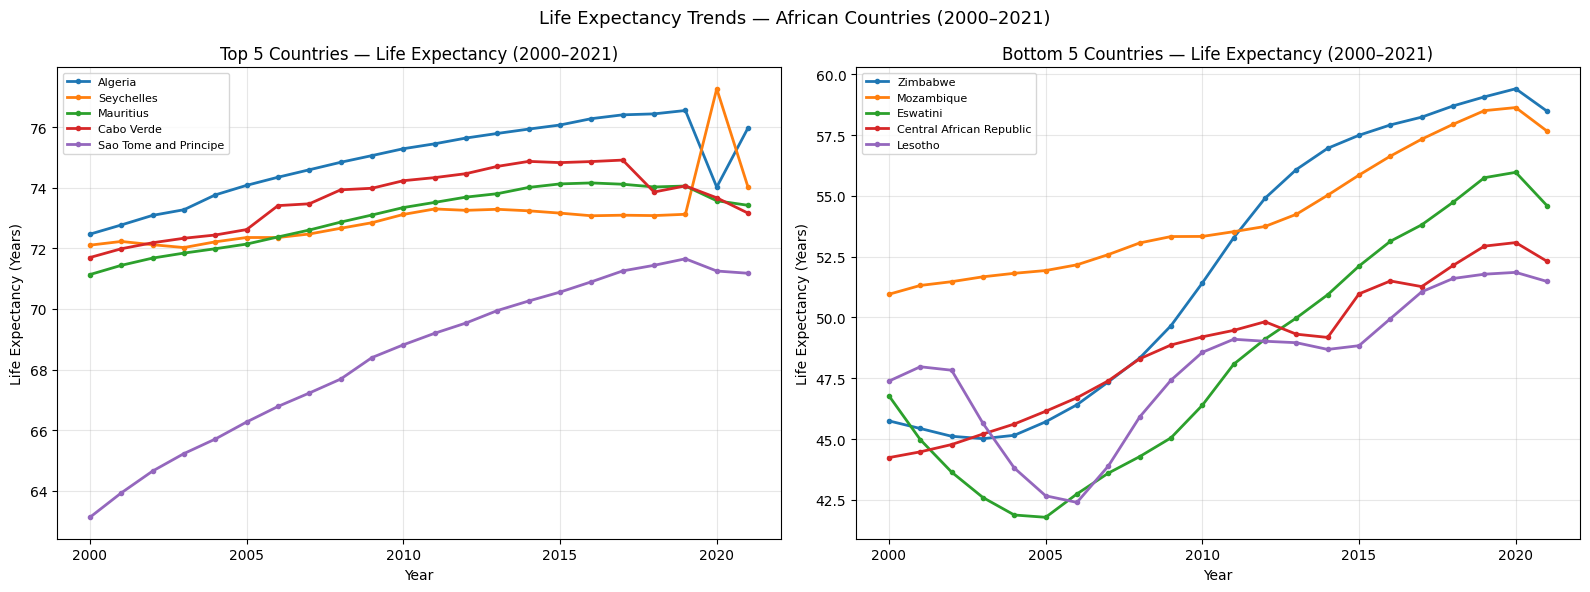

In [5]:
top5 = latest_2021.head(5)['Country_Code'].tolist()
bottom5 = latest_2021.tail(5)['Country_Code'].tolist()
highlight = top5 + bottom5

df_highlight = df_combined[df_combined['Country_Code'].isin(highlight)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top 5
for code in top5:
    country_data = df_highlight[df_highlight['Country_Code'] == code]
    name = country_data['Country_Name'].iloc[0]
    axes[0].plot(country_data['Year'], country_data['Life_Expectancy'],
                 marker='o', markersize=3, label=name, linewidth=2)
axes[0].set_title('Top 5 Countries — Life Expectancy (2000–2021)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Life Expectancy (Years)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# bottom 5
for code in bottom5:
    country_data = df_highlight[df_highlight['Country_Code'] == code]
    name = country_data['Country_Name'].iloc[0]
    axes[1].plot(country_data['Year'], country_data['Life_Expectancy'],
                 marker='o', markersize=3, label=name, linewidth=2)
axes[1].set_title('Bottom 5 Countries — Life Expectancy (2000–2021)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Life Expectancy (Years)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Life Expectancy Trends — African Countries (2000–2021)', fontsize=13)
plt.tight_layout()
plt.savefig('chart1_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: North African and island nations lead life expectancy (73-76 years).
# Southern African countries show dramatic improvement post-2005
# reflecting HIV/AIDS antiretroviral treatment scale-up.

## 5. Life Expectancy Rankings Across Africa (2021)

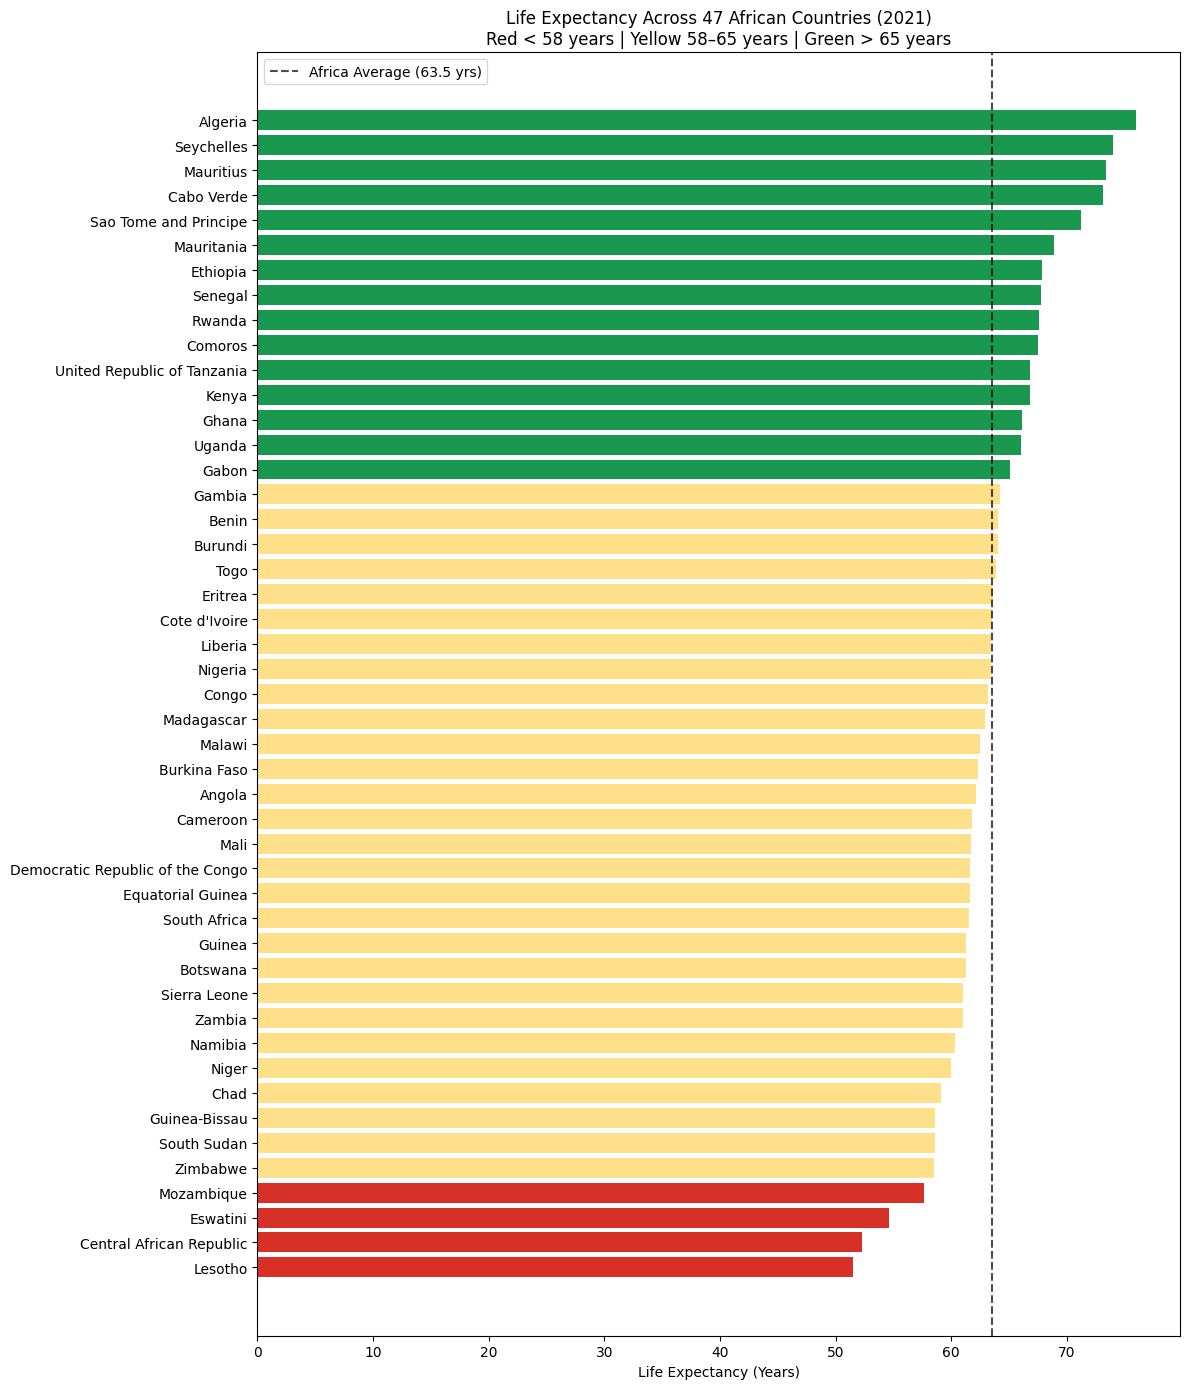

In [6]:
ranked = latest_2021.sort_values('Life_Expectancy', ascending=True)

plt.figure(figsize=(12, 14))
colors = ['#d73027' if v < 58 else '#fee08b' if v < 65 else '#1a9850'
          for v in ranked['Life_Expectancy']]
plt.barh(ranked['Country_Name'], ranked['Life_Expectancy'], color=colors)
plt.xlabel('Life Expectancy (Years)')
plt.title('Life Expectancy Across 47 African Countries (2021)\n'
          'Red < 58 years | Yellow 58–65 years | Green > 65 years')
plt.axvline(x=ranked['Life_Expectancy'].mean(), color='black',
            linestyle='--', alpha=0.7, label=f"Africa Average ({ranked['Life_Expectancy'].mean():.1f} yrs)")
plt.legend()
plt.tight_layout()
plt.savefig('chart2_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ghana Deep Dive

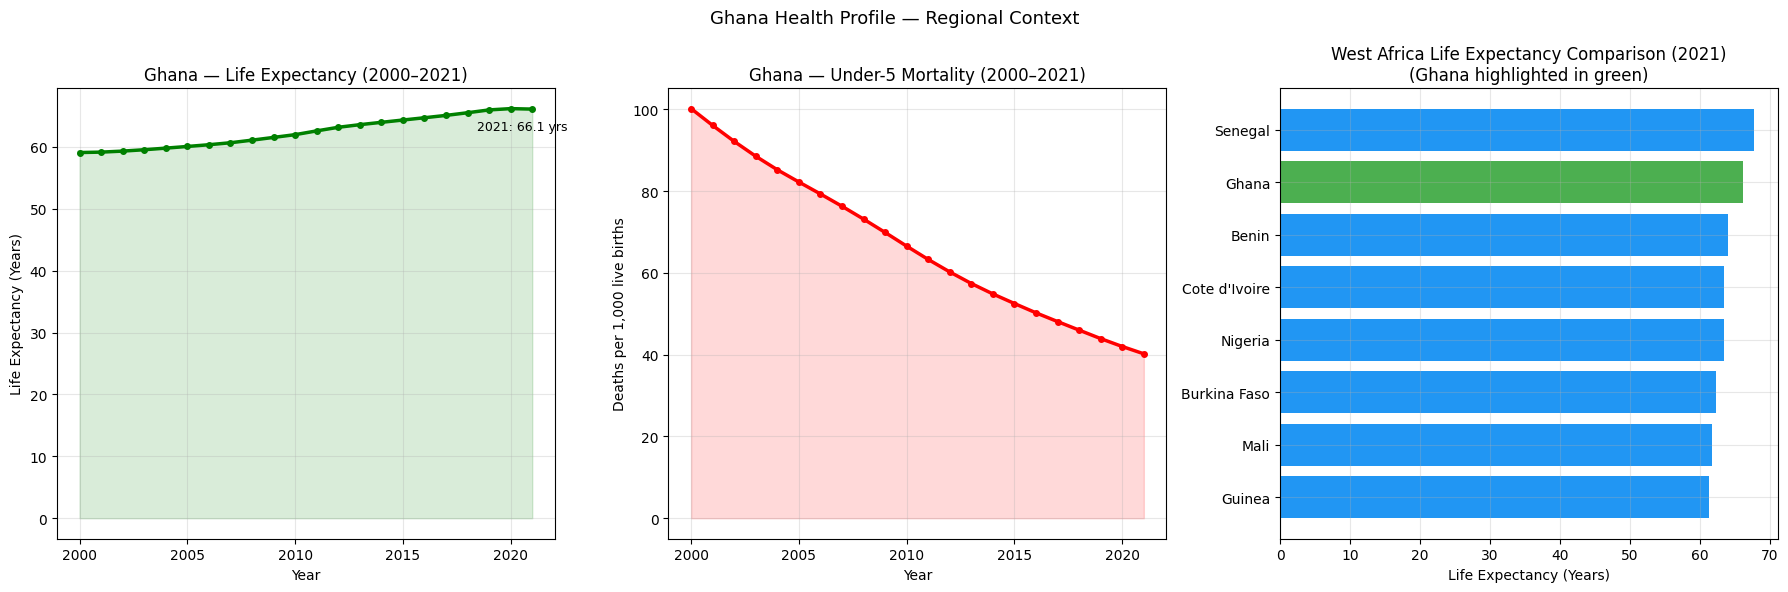

Ghana Summary (2017-2021):
     Year  Life_Expectancy  Under5_Mortality
369  2017             65.1              48.1
370  2018             65.5              46.0
371  2019             66.0              43.9
372  2020             66.2              42.0
373  2021             66.1              40.2


In [7]:
ghana = df_combined[df_combined['Country_Code'] == 'GHA'].copy()

# west africa comparison
west_africa = ['GHA', 'NGA', 'SEN', 'CIV', 'BFA', 'MLI', 'GIN', 'BEN']
df_wa = df_combined[df_combined['Country_Code'].isin(west_africa)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ghana life expectancy trend
axes[0].plot(ghana['Year'], ghana['Life_Expectancy'],
             color='green', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(ghana['Year'], ghana['Life_Expectancy'],
                     alpha=0.15, color='green')
axes[0].set_title('Ghana — Life Expectancy (2000–2021)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Life Expectancy (Years)')
axes[0].grid(alpha=0.3)
axes[0].annotate(f"2021: {ghana[ghana['Year']==2021]['Life_Expectancy'].values[0]:.1f} yrs",
                 xy=(2021, ghana[ghana['Year']==2021]['Life_Expectancy'].values[0]),
                 xytext=(-40, -15), textcoords='offset points', fontsize=9)

# ghana under-5 mortality trend
axes[1].plot(ghana['Year'], ghana['Under5_Mortality'],
             color='red', linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(ghana['Year'], ghana['Under5_Mortality'],
                     alpha=0.15, color='red')
axes[1].set_title('Ghana — Under-5 Mortality (2000–2021)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Deaths per 1,000 live births')
axes[1].grid(alpha=0.3)

# west africa comparison (2021)
wa_2021 = df_wa[df_wa['Year'] == 2021].sort_values('Life_Expectancy', ascending=True)
colors_wa = ['#2196F3' if c != 'GHA' else '#4CAF50'
             for c in wa_2021['Country_Code']]
axes[2].barh(wa_2021['Country_Name'], wa_2021['Life_Expectancy'], color=colors_wa)
axes[2].set_title('West Africa Life Expectancy Comparison (2021)\n(Ghana highlighted in green)')
axes[2].set_xlabel('Life Expectancy (Years)')
axes[2].grid(alpha=0.3)

plt.suptitle('Ghana Health Profile — Regional Context', fontsize=13)
plt.tight_layout()
plt.savefig('chart3_ghana.png', dpi=150, bbox_inches='tight')
plt.show()

print("Ghana Summary (2017-2021):")
print(ghana[['Year','Life_Expectancy','Under5_Mortality']].tail(5).round(1).to_string())

# Insight: Ghana gained 7 years of life expectancy between 2000-2021.
# Under-5 mortality fell 60% — from 100 to 40 per 1,000 live births.
# Ghana ranks among the top performers in West Africa.

## 7. Life Expectancy vs Child Mortality (2021)

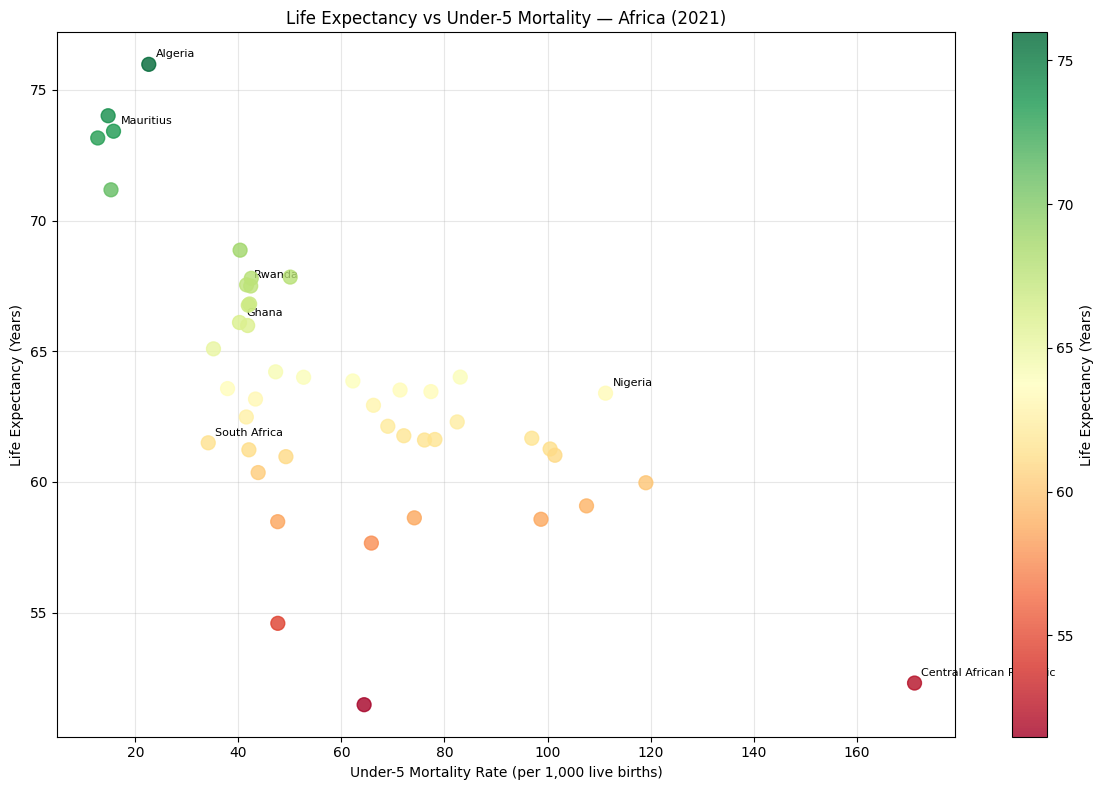

In [8]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    latest_2021['Under5_Mortality'],
    latest_2021['Life_Expectancy'],
    c=latest_2021['Life_Expectancy'],
    cmap='RdYlGn', s=100, alpha=0.8, zorder=5
)
plt.colorbar(scatter, label='Life Expectancy (Years)')

# label notable countries
label_countries = ['GHA', 'NGA', 'RWA', 'ZAF', 'CAF', 'DZA', 'MUS']
for _, row in latest_2021.iterrows():
    if row['Country_Code'] in label_countries:
        plt.annotate(row['Country_Name'],
                     xy=(row['Under5_Mortality'], row['Life_Expectancy']),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('Under-5 Mortality Rate (per 1,000 live births)')
plt.ylabel('Life Expectancy (Years)')
plt.title('Life Expectancy vs Under-5 Mortality — Africa (2021)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Strong negative correlation — countries with high child mortality
# have significantly lower life expectancy. Investing in child survival
# has outsized population health returns.

## 8. Top 15 Improvers — Life Expectancy Gained (2000–2021)

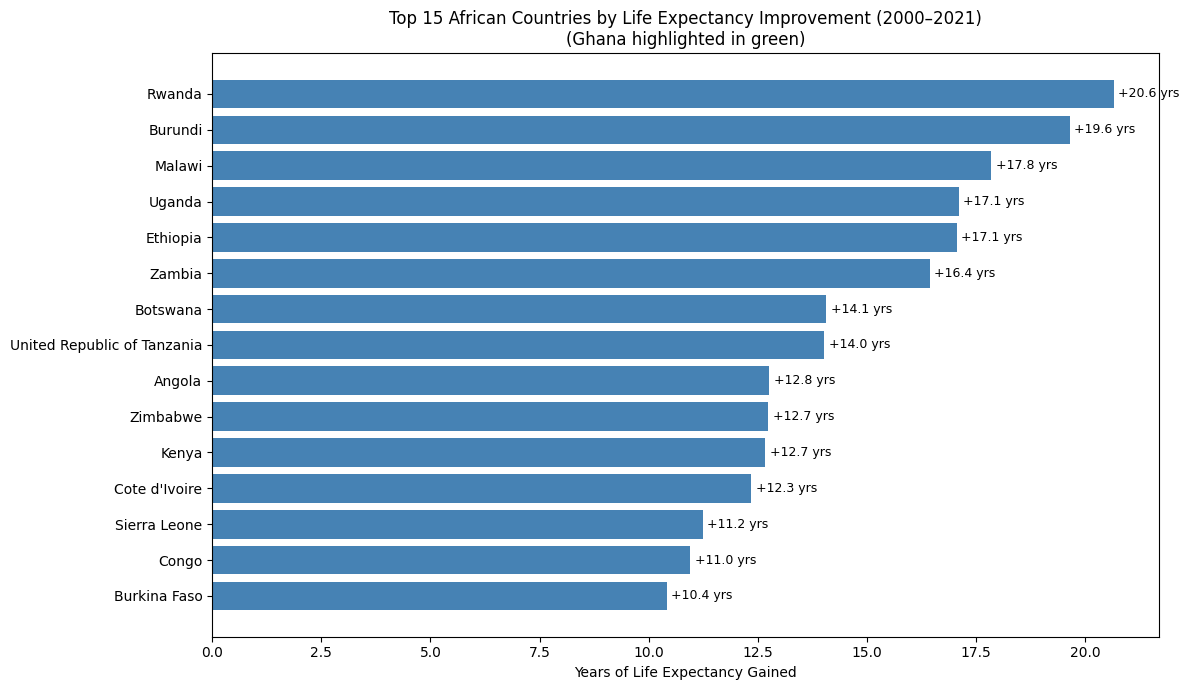

Top 10 improvers:
                   Country_Name  LE_2000  LE_2021  Improvement
33                       Rwanda     46.9     67.5         20.6
1                       Burundi     44.4     64.0         19.6
29                       Malawi     44.6     62.5         17.8
43                       Uganda     48.9     66.0         17.1
14                     Ethiopia     50.8     67.8         17.1
45                       Zambia     44.5     61.0         16.4
4                      Botswana     47.2     61.2         14.1
42  United Republic of Tanzania     52.8     66.8         14.0
0                        Angola     49.4     62.1         12.8
46                     Zimbabwe     45.7     58.5         12.7


In [9]:
progress = df_combined[df_combined['Year'].isin([2000, 2021])]
progress = progress.groupby(
    ['Country_Code', 'Country_Name', 'Year']
)['Life_Expectancy'].mean().reset_index()

progress_wide = progress.pivot(
    index=['Country_Code', 'Country_Name'],
    columns='Year', values='Life_Expectancy'
).reset_index()
progress_wide.columns = ['Country_Code', 'Country_Name', 'LE_2000', 'LE_2021']
progress_wide['Improvement'] = progress_wide['LE_2021'] - progress_wide['LE_2000']
progress_wide = progress_wide.sort_values('Improvement', ascending=False)

top15 = progress_wide.head(15)

plt.figure(figsize=(12, 7))
colors = ['#4CAF50' if c == 'GHA' else 'steelblue'
          for c in top15['Country_Code']]
bars = plt.barh(top15['Country_Name'], top15['Improvement'], color=colors)
plt.xlabel('Years of Life Expectancy Gained')
plt.title('Top 15 African Countries by Life Expectancy Improvement (2000–2021)\n(Ghana highlighted in green)')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top15['Improvement']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'+{val:.1f} yrs', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_improvers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 improvers:")
print(progress_wide[['Country_Name','LE_2000','LE_2021','Improvement']].head(10).round(1).to_string())

# Insight: Rwanda gained 20.6 years — among the fastest improvements in
# recorded public health history. Reflects post-genocide reconstruction,
# universal health coverage, and Africa's strongest CHW program.

## 9. Conclusions

| Finding | Implication |
|---|---|
| **23-year life expectancy gap within Africa** | Algeria/Mauritius at 75+ vs CAR at 52 — same continent, vastly different health systems |
| **Rwanda gained 20.6 years in 21 years** | Community health workers + UHC = transformative population health impact |
| **Ghana gained 7 years, cut child mortality 60%** | NHIS and primary healthcare expansion measurably visible in the data |
| **HIV/AIDS treatment scale-up is visible** | Zimbabwe, Malawi, Zambia show sharp upturns post-2005 |
| **Child mortality strongly predicts life expectancy** | Investing in child survival has outsized population health returns |
| **Ghana ranks top in West Africa** | Regional model for health system strengthening |

---

**Data Source:** WHO Global Health Observatory API  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)